# Trabajo Fin de Máster
# Business Analytics aplicado a FOOD&FUN: análisis, predicción y optimización para la toma de decisiones

## Análisis predictivo de la ocupación mediante técnicas de Machine Learning

**Autora:** Francisca Concha

**Máster en Business Analytics e Inteligencia de Negocio**

**Universidad Católica de Valencia**

**Curso académico 2025–2026**


# 1. Análisis Exploratorio de Datos (EDA)

In [174]:
# Importación de librerías

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [175]:
# Carga del fichero Excel

ruta = "/Users/fran/Desktop/UCV Master /TFM/TFM VSC/Compras_2526_F&F.xlsx"

df = pd.read_excel(ruta)

# Visualización inicial

df.head()

,Fecha de Compra,Número de Pedido,Taller,Fecha Taller,Cantidad de Plazas,TARJETAS REGALO,Importe Total,IMPORTE DEVOLUCIÓN,Método de Pago
0,2024-11-18,43856526,Tarjeta Regalo,NaN,0,1.0,150.0,NaN,Visa
1,2025-01-01,43861545,Kimchi,2025-03-24 00:00:00,2,NaN,180.0,NaN,Bizum
2,2025-01-01,43861547,Tarjeta Regalo,NaN,0,1.0,90.0,NaN,Visa
3,2025-01-01,43861597,Tarjeta Regalo,NaN,0,0.0,0.0,NaN,Devolución
4,2025-01-01,43861549,Ramen,2025-03-28 00:00:00,2,NaN,162.0,NaN,Visa


In [176]:
# Número de filas y columnas

df.shape

(1409, 9)

In [177]:
# Tipos de datos

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha de Compra     1409 non-null   datetime64[us]
 1   Número de Pedido    1409 non-null   int64         
 2   Taller              1409 non-null   str           
 3   Fecha Taller        1029 non-null   object        
 4   Cantidad de Plazas  1409 non-null   int64         
 5   TARJETAS REGALO     363 non-null    float64       
 6   Importe Total       1409 non-null   float64       
 7   IMPORTE DEVOLUCIÓN  12 non-null     float64       
 8   Método de Pago      1409 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(2), object(1), str(2)
memory usage: 99.2+ KB


In [178]:
# Convertir Fecha Taller a formato fecha

df["Fecha Taller"] = pd.to_datetime(
    df["Fecha Taller"],
    errors="coerce"
)

In [179]:
# Revisamos tipos de datos

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha de Compra     1409 non-null   datetime64[us]
 1   Número de Pedido    1409 non-null   int64         
 2   Taller              1409 non-null   str           
 3   Fecha Taller        1026 non-null   datetime64[us]
 4   Cantidad de Plazas  1409 non-null   int64         
 5   TARJETAS REGALO     363 non-null    float64       
 6   Importe Total       1409 non-null   float64       
 7   IMPORTE DEVOLUCIÓN  12 non-null     float64       
 8   Método de Pago      1409 non-null   str           
dtypes: datetime64[us](2), float64(3), int64(2), str(2)
memory usage: 99.2 KB


In [180]:
# Valores nulos

df.isnull().sum()

Fecha de Compra          0
Número de Pedido         0
Taller                   0
Fecha Taller           383
Cantidad de Plazas       0
TARJETAS REGALO       1046
Importe Total            0
IMPORTE DEVOLUCIÓN    1397
Método de Pago           0
dtype: int64

In [181]:
df[df["Fecha Taller"].isna()]["Taller"].value_counts()

Taller
Tarjeta Regalo                  362
Esperando selección de curso     13
Cocas Miquel Ruiz                 2
Raíces                            1
Reposteria                        1
Curso Cocina Mexicana             1
Tapas Españolas                   1
Kimchi                            1
Croquetas                         1
Name: count, dtype: int64

In [182]:
# Convertir a fecha y transformar valores no válidos en NaT

df["Fecha Taller"] = pd.to_datetime(
    df["Fecha Taller"],
    errors="coerce"
)

In [183]:
# Si no se utilizó tarjeta regalo, se asume 0

df["TARJETAS REGALO"] = (
    df["TARJETAS REGALO"]
    .fillna(0)
)

In [184]:
# Si no hubo devolución, se asume 0

df["IMPORTE DEVOLUCIÓN"] = (
    df["IMPORTE DEVOLUCIÓN"]
    .fillna(0)
)

In [185]:
df.isnull().sum()

Fecha de Compra         0
Número de Pedido        0
Taller                  0
Fecha Taller          383
Cantidad de Plazas      0
TARJETAS REGALO         0
Importe Total           0
IMPORTE DEVOLUCIÓN      0
Método de Pago          0
dtype: int64

In [186]:
# Número de productos diferentes

df["Taller"].nunique()

18

In [187]:
# Productos más frecuentes

df["Taller"].value_counts().head(20)

Taller
Tarjeta Regalo                  376
Curso de Arroces                200
Paella Lovers                   142
Sushi                           136
Ramen                           113
Raíces                           96
Tapas Españolas                  82
Kimchi                           78
Reposteria                       54
Taller de Pasta Fresca           30
Taller de Principiantes          28
Esperando selección de curso     19
Cocas Miquel Ruiz                18
Curso Cocina Mexicana            13
Taller de Curry                  11
Croquetas                         5
NOBLE                             4
Clasicos Valencianos              4
Name: count, dtype: int64

## 1.1 Objetivo del proyecto

Predicción de ocupación de cursos

Objetivo:

Predecir cuántos asistentes tendrá cada curso de Food & Fun.

Actualmente cada fila del dataset representa una compra realizada por un cliente.

Por tanto, será necesario transformar los datos para construir una nueva tabla donde cada fila represente una edición concreta de un curso y la variable objetivo sea el número de asistentes registrados.

## 1.2 Análisis de la variable objetivo

In [188]:
# Eliminar tarjetas regalo y cursos sin asignar

df_talleres = df[
    ~df["Taller"].isin(
        [
            "Tarjeta Regalo",
            "Esperando selección de curso"
        ]
    )
].copy()

In [189]:
# Número total de plazas vendidas por taller

df_talleres.groupby("Taller")["Cantidad de Plazas"].sum() \
           .sort_values(ascending=False) \
           .head(15)

Taller
Curso de Arroces           314
Paella Lovers              247
Sushi                      220
Ramen                      159
Tapas Españolas            146
Raíces                     124
Kimchi                     104
Taller de Pasta Fresca      75
Reposteria                  62
Taller de Principiantes     32
Cocas Miquel Ruiz           25
Curso Cocina Mexicana       20
Taller de Curry             13
Croquetas                    8
NOBLE                        4
Name: Cantidad de Plazas, dtype: int64

In [190]:
# Estadísticas descriptivas de la ocupación de los talleres

df_talleres["Cantidad de Plazas"].describe()

count    1014.000000
mean        1.534517
std         1.138179
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        14.000000
Name: Cantidad de Plazas, dtype: float64

In [191]:
# Distribución del número de plazas compradas

df_talleres["Cantidad de Plazas"].value_counts().sort_index()

Cantidad de Plazas
0      41
1     556
2     355
3      26
4      17
5       3
6       7
7       2
8       2
9       1
10      1
12      2
14      1
Name: count, dtype: int64

## 1.3 Construcción de la variable objetivo

In [192]:
ocupacion_talleres = (
    df_talleres
    .groupby(["Taller", "Fecha Taller"])["Cantidad de Plazas"]
    .sum()
    .reset_index(name="Asistentes")
)

In [193]:
ocupacion_talleres.head(20)

,Taller,Fecha Taller,Asistentes
0,Clasicos Valencianos,2026-03-29,0
1,Clasicos Valencianos,2026-06-13,3
2,Cocas Miquel Ruiz,2025-07-12,25
3,Croquetas,2026-04-18,3
4,Croquetas,2026-05-30,3
5,Curso Cocina Mexicana,2025-07-11,5
6,Curso Cocina Mexicana,2025-09-12,0
7,Curso Cocina Mexicana,2025-10-31,14
8,Curso de Arroces,2025-01-18,1
9,Curso de Arroces,2025-02-22,14


In [194]:
ocupacion_talleres

,Taller,Fecha Taller,Asistentes
0,Clasicos Valencianos,2026-03-29,0
1,Clasicos Valencianos,2026-06-13,3
2,Cocas Miquel Ruiz,2025-07-12,25
3,Croquetas,2026-04-18,3
4,Croquetas,2026-05-30,3
...,...,...,...
138,Tapas Españolas,2026-03-06,7
139,Tapas Españolas,2026-03-18,10
140,Tapas Españolas,2026-05-09,6
141,Tapas Españolas,2026-06-05,9


In [195]:
ocupacion_talleres.sort_values(
    by="Asistentes",
    ascending=False
).head(20)

,Taller,Fecha Taller,Asistentes
84,Raíces,2025-06-28,35
83,Raíces,2025-05-24,33
82,Raíces,2025-04-12,31
2,Cocas Miquel Ruiz,2025-07-12,25
81,Raíces,2025-03-29,23
71,Ramen,2025-05-09,22
22,Curso de Arroces,2025-12-13,21
115,Taller de Pasta Fresca,2025-09-26,20
35,Kimchi,2025-12-01,20
20,Curso de Arroces,2025-10-18,20


In [196]:
ocupacion_talleres.shape

(143, 3)

* 143 talleres distintos celebrados
* 3 columnas

In [197]:
ocupacion_talleres.to_excel(
    "ocupacion_talleres.xlsx",
    index=False
)

In [198]:
ocupacion_talleres.shape
ocupacion_talleres.head()
ocupacion_talleres["Asistentes"].describe()

count    143.00000
mean      10.86014
std        6.97743
min        0.00000
25%        5.00000
50%       12.00000
75%       15.00000
max       35.00000
Name: Asistentes, dtype: float64

Dado que cada registro del conjunto de datos original representaba una compra individual, fue necesario transformar la información para construir la variable objetivo del modelo. Para ello, se agruparon las compras por taller y fecha de celebración, sumando el número de plazas adquiridas en cada edición. El resultado es un nuevo conjunto de datos donde cada fila representa un taller concreto y la variable objetivo corresponde al número total de asistentes.

## 1.4 Análisis de la ocupación de los talleres

In [199]:
ocupacion_talleres["Asistentes"].describe()

count    143.00000
mean      10.86014
std        6.97743
min        0.00000
25%        5.00000
50%       12.00000
75%       15.00000
max       35.00000
Name: Asistentes, dtype: float64

In [200]:
ocupacion_talleres["Asistentes"].sum()

np.int64(1553)

In [201]:
print("Total asistentes:", ocupacion_talleres["Asistentes"].sum())

print("Número de talleres celebrados:",
      ocupacion_talleres.shape[0])

Total asistentes: 1553
Número de talleres celebrados: 143


## 1.5 Evolución temporal de la ocupación

In [202]:
# Año del taller

ocupacion_talleres["Año"] = (
    ocupacion_talleres["Fecha Taller"].dt.year
)

# Mes del taller

ocupacion_talleres["Mes"] = (
    ocupacion_talleres["Fecha Taller"].dt.month
)

In [203]:
ocupacion_mes = (
    ocupacion_talleres
    .groupby("Mes")["Asistentes"]
    .mean()
    .sort_index()
)

ocupacion_mes

Mes
1     11.250000
2     11.681818
3      9.680000
4      9.888889
5     13.352941
6      9.263158
7      8.000000
9     11.250000
10    13.500000
11    10.750000
12    15.500000
Name: Asistentes, dtype: float64

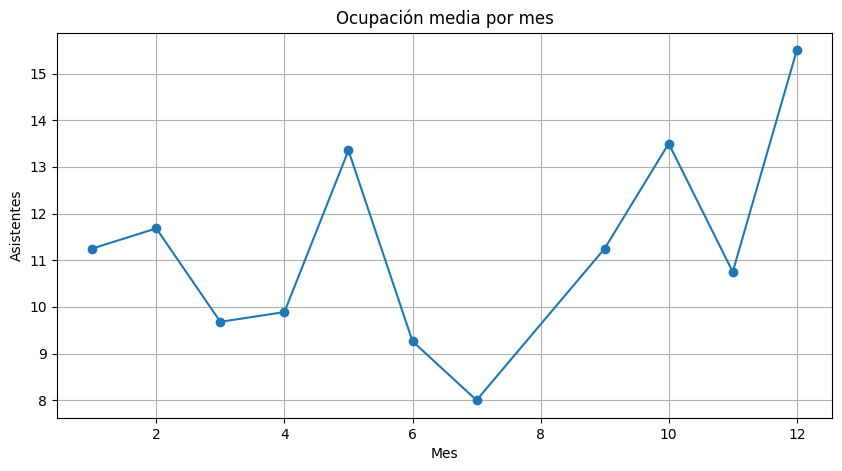

In [204]:
plt.figure(figsize=(10,5))

plt.plot(
    ocupacion_mes.index,
    ocupacion_mes.values,
    marker="o"
)

plt.title("Ocupación media por mes")
plt.xlabel("Mes")
plt.ylabel("Asistentes")

plt.grid(True)

plt.show()

Esto responde a la pregunta:
ej:
"Cuando se celebra un taller en marzo, ¿cuántos asistentes tiene de media ese taller?"

In [205]:
ocupacion_total_mes = (
    ocupacion_talleres
    .groupby("Mes")["Asistentes"]
    .sum()
    .sort_index()
)

ocupacion_total_mes

Mes
1      90
2     257
3     242
4     178
5     227
6     176
7      80
9      90
10    108
11     43
12     62
Name: Asistentes, dtype: int64

In [206]:
#Ocupación media por taller
ocupacion_media_mes = (
    ocupacion_talleres
    .groupby("Mes")["Asistentes"]
    .mean()
    .sort_index()
)

ocupacion_media_mes

Mes
1     11.250000
2     11.681818
3      9.680000
4      9.888889
5     13.352941
6      9.263158
7      8.000000
9     11.250000
10    13.500000
11    10.750000
12    15.500000
Name: Asistentes, dtype: float64

In [207]:
resumen_mes = (
    ocupacion_talleres
    .groupby("Mes")["Asistentes"]
    .agg(["count", "sum", "mean"])
    .sort_index()
)

resumen_mes

,count,sum,mean
Mes,,,
1,8,90,11.250000
2,22,257,11.681818
3,25,242,9.680000
4,18,178,9.888889
5,17,227,13.352941
6,19,176,9.263158
7,10,80,8.000000
9,8,90,11.250000
10,8,108,13.500000


* count = número de talleres celebrados.
* sum = asistentes totales del mes.
* mean = ocupación media por taller.

### Conclusiones rápidas
* Febrero y marzo son los meses con más talleres celebrados (22 y 25).
* Febrero es el mes con más asistentes totales (257).
* Diciembre tiene la mayor ocupación media (15.5 asistentes por taller), aunque solo hay 4 talleres.
* Julio presenta la ocupación media más baja (8 asistentes por taller).

## 1.6 Distribución de la ocupación

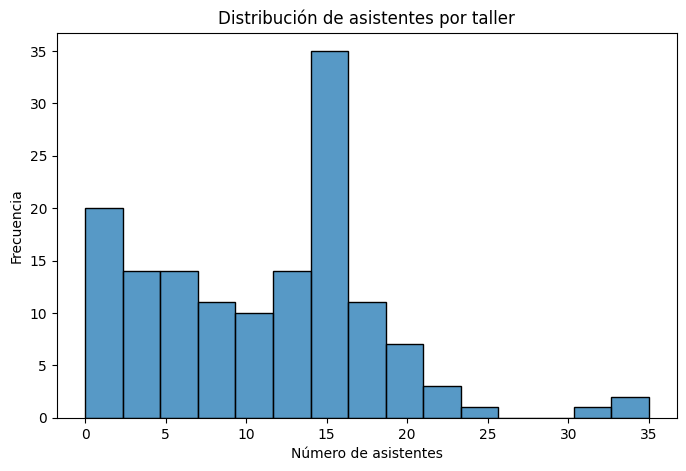

In [208]:
plt.figure(figsize=(8,5))

sns.histplot(
    ocupacion_talleres["Asistentes"],
    bins=15
)

plt.title("Distribución de asistentes por taller")
plt.xlabel("Número de asistentes")
plt.ylabel("Frecuencia")

plt.show()

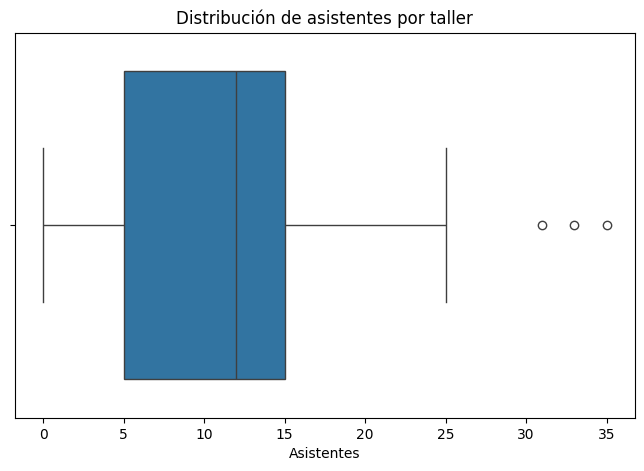

In [209]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=ocupacion_talleres["Asistentes"]
)

plt.title("Distribución de asistentes por taller")

plt.show()

## 1.7 Ranking de talleres

In [210]:
ranking_talleres = (
    ocupacion_talleres
    .groupby("Taller")["Asistentes"]
    .mean()
    .sort_values(ascending=False)
)

ranking_talleres

Taller
Cocas Miquel Ruiz          25.000000
Raíces                     20.666667
Kimchi                     17.333333
Ramen                      13.250000
Curso de Arroces           13.083333
Sushi                      11.578947
Taller de Pasta Fresca     10.714286
Paella Lovers               8.821429
Tapas Españolas             8.111111
Taller de Principiantes     8.000000
Reposteria                  7.750000
Taller de Curry             6.500000
Curso Cocina Mexicana       6.333333
NOBLE                       4.000000
Croquetas                   3.000000
Clasicos Valencianos        1.500000
Name: Asistentes, dtype: float64

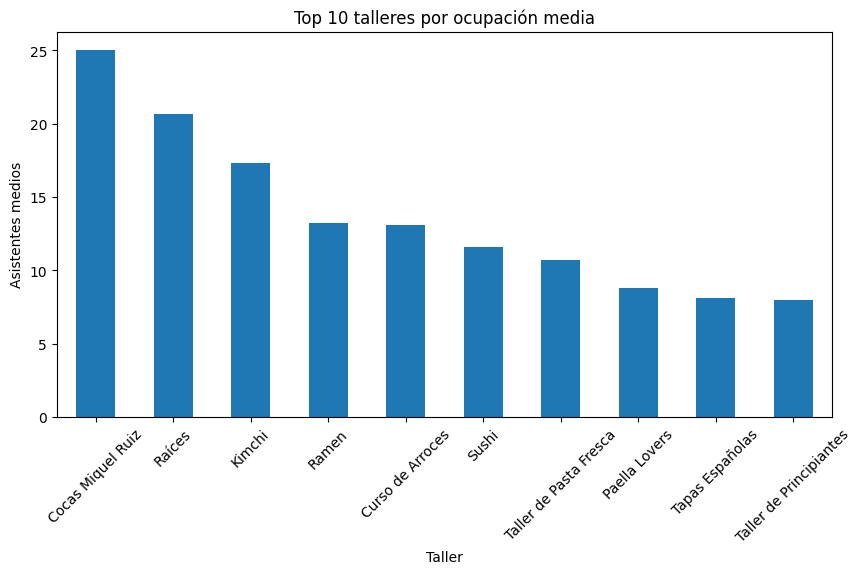

In [211]:
plt.figure(figsize=(10,5))

ranking_talleres.head(10).plot(
    kind="bar"
)

plt.title("Top 10 talleres por ocupación media")
plt.xlabel("Taller")
plt.ylabel("Asistentes medios")

plt.xticks(rotation=45)

plt.show()

# 2. Preparación de los datos para la predicción de ocupación

In [212]:
ocupacion_talleres.shape

(143, 5)

In [213]:
ocupacion_talleres.head()

,Taller,Fecha Taller,Asistentes,Año,Mes
0,Clasicos Valencianos,2026-03-29,0,2026,3
1,Clasicos Valencianos,2026-06-13,3,2026,6
2,Cocas Miquel Ruiz,2025-07-12,25,2025,7
3,Croquetas,2026-04-18,3,2026,4
4,Croquetas,2026-05-30,3,2026,5


In [214]:
# Talleres sin asistentes

ocupacion_talleres[
    ocupacion_talleres["Asistentes"] == 0
].shape

(7, 5)

In [215]:
ocupacion_talleres[
    ocupacion_talleres["Asistentes"] == 0
]

,Taller,Fecha Taller,Asistentes,Año,Mes
0,Clasicos Valencianos,2026-03-29,0,2026,3
6,Curso Cocina Mexicana,2025-09-12,0,2025,9
50,Paella Lovers,2025-06-21,0,2025,6
51,Paella Lovers,2025-07-05,0,2025,7
88,Reposteria,2025-07-06,0,2025,7
99,Sushi,2025-10-10,0,2025,10
134,Tapas Españolas,2025-11-21,0,2025,11


## 2.1 Construcción de variables temporales

In [216]:
# Día de la semana

ocupacion_talleres["Dia_Semana"] = (
    ocupacion_talleres["Fecha Taller"]
    .dt.dayofweek
)

# Trimestre

ocupacion_talleres["Trimestre"] = (
    ocupacion_talleres["Fecha Taller"]
    .dt.quarter
)

# Semana del año

ocupacion_talleres["Semana_Año"] = (
    ocupacion_talleres["Fecha Taller"]
    .dt.isocalendar()
    .week
)

In [217]:
ocupacion_talleres.head()

,Taller,Fecha Taller,Asistentes,Año,Mes,Dia_Semana,Trimestre,Semana_Año
0,Clasicos Valencianos,2026-03-29,0,2026,3,6,1,13
1,Clasicos Valencianos,2026-06-13,3,2026,6,5,2,24
2,Cocas Miquel Ruiz,2025-07-12,25,2025,7,5,3,28
3,Croquetas,2026-04-18,3,2026,4,5,2,16
4,Croquetas,2026-05-30,3,2026,5,5,2,22


## 2.2 Distribución temporal de talleres

In [218]:
ocupacion_talleres.groupby("Mes")["Asistentes"].mean()

Mes
1     11.250000
2     11.681818
3      9.680000
4      9.888889
5     13.352941
6      9.263158
7      8.000000
9     11.250000
10    13.500000
11    10.750000
12    15.500000
Name: Asistentes, dtype: float64

In [219]:
ocupacion_talleres.groupby("Dia_Semana")["Asistentes"].mean()

Dia_Semana
0    12.583333
2     8.000000
3     3.000000
4    10.750000
5    11.772727
6     6.166667
Name: Asistentes, dtype: float64

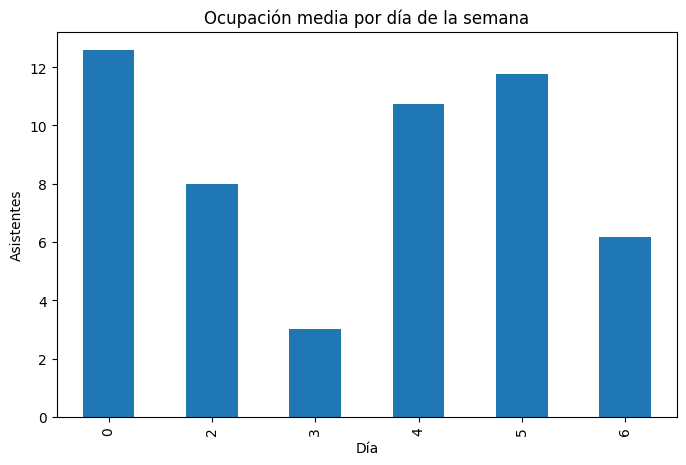

In [220]:
plt.figure(figsize=(8,5))

ocupacion_talleres.groupby(
    "Dia_Semana"
)["Asistentes"].mean().plot(
    kind="bar"
)

plt.title("Ocupación media por día de la semana")
plt.xlabel("Día")
plt.ylabel("Asistentes")

plt.show()

| Número | Día       |
| ------ | --------- |
| 0      | Lunes     |
| 1      | Martes    |
| 2      | Miércoles |
| 3      | Jueves    |
| 4      | Viernes   |
| 5      | Sábado    |
| 6      | Domingo   |


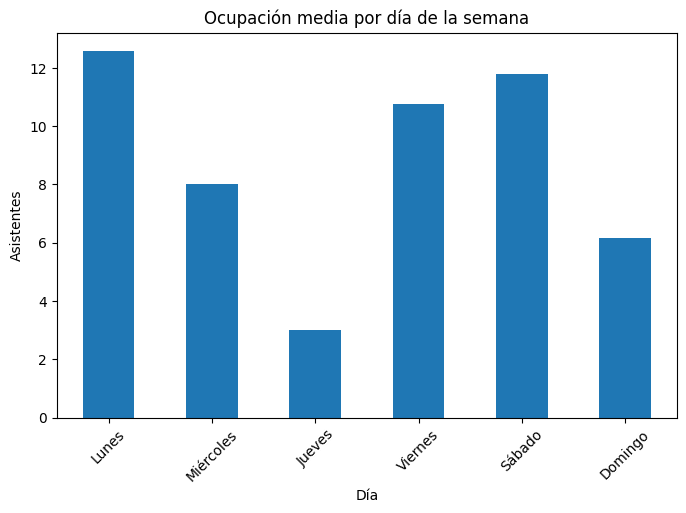

In [221]:
dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}

ocupacion_dia = (
    ocupacion_talleres
    .groupby("Dia_Semana")["Asistentes"]
    .mean()
)

ocupacion_dia.index = [
    dias[d]
    for d in ocupacion_dia.index
]

plt.figure(figsize=(8,5))

ocupacion_dia.plot(
    kind="bar"
)

plt.title("Ocupación media por día de la semana")
plt.xlabel("Día")
plt.ylabel("Asistentes")

plt.xticks(rotation=45)

plt.show()

## 2.3 Análisis por taller

In [222]:
ocupacion_talleres.groupby(
    "Taller"
)["Asistentes"].mean().sort_values(
    ascending=False
)

Taller
Cocas Miquel Ruiz          25.000000
Raíces                     20.666667
Kimchi                     17.333333
Ramen                      13.250000
Curso de Arroces           13.083333
Sushi                      11.578947
Taller de Pasta Fresca     10.714286
Paella Lovers               8.821429
Tapas Españolas             8.111111
Taller de Principiantes     8.000000
Reposteria                  7.750000
Taller de Curry             6.500000
Curso Cocina Mexicana       6.333333
NOBLE                       4.000000
Croquetas                   3.000000
Clasicos Valencianos        1.500000
Name: Asistentes, dtype: float64

## 2.4 Preparación para el modelo

In [223]:
ocupacion_talleres.isnull().sum()

Taller          0
Fecha Taller    0
Asistentes      0
Año             0
Mes             0
Dia_Semana      0
Trimestre       0
Semana_Año      0
dtype: int64

In [224]:
ocupacion_talleres[
    [
        "Asistentes",
        "Año",
        "Mes",
        "Dia_Semana",
        "Trimestre",
        "Semana_Año"
    ]
].corr(numeric_only=True)

,Asistentes,Año,Mes,Dia_Semana,Trimestre,Semana_Año
Asistentes,1.000000,-0.119447,0.058900,-0.070693,0.063029,0.065211
Año,-0.119447,1.000000,-0.370124,0.001468,-0.375237,-0.362261
Mes,0.058900,-0.370124,1.000000,0.034050,0.959098,0.995348
Dia_Semana,-0.070693,0.001468,0.034050,1.000000,0.029624,0.018983
Trimestre,0.063029,-0.375237,0.959098,0.029624,1.000000,0.952943
Semana_Año,0.065211,-0.362261,0.995348,0.018983,0.952943,1.000000


Las variables temporales presentan una correlación lineal débil con la ocupación de los talleres. Esto sugiere que la asistencia no depende únicamente del momento temporal, sino que probablemente está influida por otros factores, especialmente el tipo de taller ofertado.

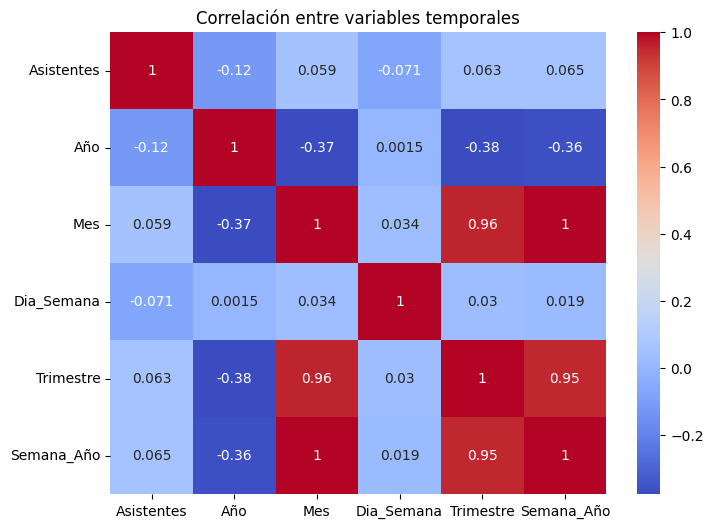

In [225]:
plt.figure(figsize=(8,6))

sns.heatmap(
    ocupacion_talleres[
        [
            "Asistentes",
            "Año",
            "Mes",
            "Dia_Semana",
            "Trimestre",
            "Semana_Año"
        ]
    ].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre variables temporales")
plt.show()

El análisis de correlación mostró una relación lineal débil entre las variables temporales y la ocupación de los talleres. Asimismo, se observó una elevada correlación entre las variables Mes, Trimestre y Semana_Año, por lo que se decidió conservar únicamente la variable Mes para evitar redundancia en los modelos predictivos.

# 2.5 Definición de variables predictoras (X) y variable objetivo (y)

In [226]:
# Variables predictoras

X = ocupacion_talleres[
    [
        "Taller",
        "Mes",
        "Dia_Semana"
    ]
]

# Variable objetivo

y = ocupacion_talleres["Asistentes"]

In [227]:
print("X:", X.shape)
print("y:", y.shape)

X.head()

X: (143, 3)
y: (143,)


,Taller,Mes,Dia_Semana
0,Clasicos Valencianos,3,6
1,Clasicos Valencianos,6,5
2,Cocas Miquel Ruiz,7,5
3,Croquetas,4,5
4,Croquetas,5,5


Se seleccionan como variables predictoras:
- Taller: tipo de curso ofertado.
- Mes: posible efecto estacional.
- Dia_Semana: posible influencia del día de celebración.

La variable objetivo será el número de asistentes al taller.

In [228]:
y.head()

0     0
1     3
2    25
3     3
4     3
Name: Asistentes, dtype: int64

In [229]:
X.dtypes

Taller          str
Mes           int32
Dia_Semana    int32
dtype: object

## 2.6 Transformación de variables categóricas

In [230]:
columns=["Taller"]

In [231]:
X.head()

,Taller,Mes,Dia_Semana
0,Clasicos Valencianos,3,6
1,Clasicos Valencianos,6,5
2,Cocas Miquel Ruiz,7,5
3,Croquetas,4,5
4,Croquetas,5,5


## 2.7 División entrenamiento/prueba

Objetivo

Antes de entrenar los modelos predictivos, es necesario dividir los datos en dos subconjuntos:

Conjunto de entrenamiento: utilizado para aprender los patrones presentes en los datos.
Conjunto de prueba: utilizado para evaluar la capacidad predictiva del modelo sobre datos no utilizados durante el entrenamiento.

In [232]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [233]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (114, 3)
X_test : (29, 3)
y_train: (114,)
y_test : (29,)


In [234]:
print("Observaciones totales:", len(X))

print(
    "Entrenamiento:",
    round(len(X_train)/len(X)*100,2),
    "%"
)

print(
    "Prueba:",
    round(len(X_test)/len(X)*100,2),
    "%"
)

Observaciones totales: 143
Entrenamiento: 79.72 %
Prueba: 20.28 %


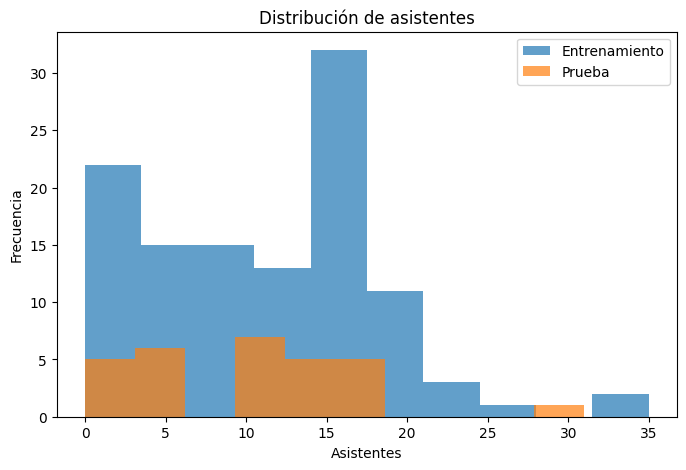

In [235]:
plt.figure(figsize=(8,5))

plt.hist(
    y_train,
    bins=10,
    alpha=0.7,
    label="Entrenamiento"
)

plt.hist(
    y_test,
    bins=10,
    alpha=0.7,
    label="Prueba"
)

plt.xlabel("Asistentes")
plt.ylabel("Frecuencia")

plt.title("Distribución de asistentes")
plt.legend()

plt.show()

El conjunto de datos se dividió en un 80% para entrenamiento y un 20% para prueba. Esta estrategia permite entrenar los modelos con una cantidad suficiente de observaciones y, al mismo tiempo, evaluar su capacidad de generalización sobre datos no utilizados durante el aprendizaje. La distribución de la variable objetivo se mantuvo similar en ambos subconjuntos, garantizando una evaluación representativa del rendimiento de los modelos.

# 3. Desarrollo de modelos predictivos

## 3.1 Modelo de Regresión Lineal

In [236]:
X_train.head()

,Taller,Mes,Dia_Semana
124,Taller de Principiantes,6,0
31,Curso de Arroces,6,5
98,Sushi,9,5
36,Kimchi,2,0
16,Curso de Arroces,7,5


In [237]:
X_train.dtypes

Taller          str
Mes           int32
Dia_Semana    int32
dtype: object

In [238]:
X_train.select_dtypes(include="object").columns

Index(['Taller'], dtype='str')

In [239]:
X = pd.get_dummies(
    X,
    columns=["Taller"],
    drop_first=True
)

In [240]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [241]:
# Entrenamiento del modelo de Regresión Lineal

from sklearn.linear_model import LinearRegression

# Creación del modelo

modelo_lr = LinearRegression()

# Ajuste del modelo utilizando los datos de entrenamiento

modelo_lr.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [242]:
# Predicción del número de asistentes

y_pred_lr = modelo_lr.predict(
    X_test
)

In [243]:
# Importación de métricas de evaluación

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# Cálculo de métricas

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

# Mostrar resultados

print("R² =", r2_lr)
print("MAE =", mae_lr)
print("RMSE =", rmse_lr)

R² = 0.27528162872708595
MAE = 4.655608118793331
RMSE = 5.661998912592698


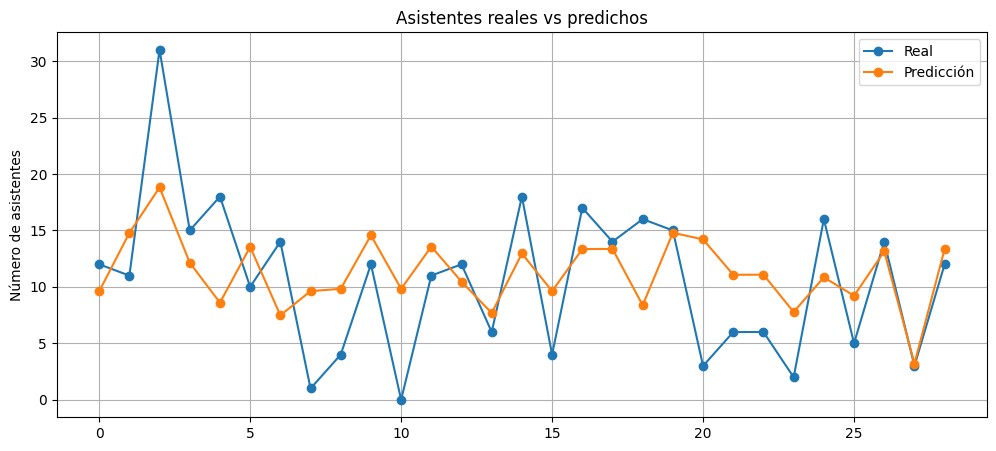

In [244]:
# Comparación gráfica entre asistentes reales y predichos

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Real",
    marker="o"
)

plt.plot(
    y_pred_lr,
    label="Predicción",
    marker="o"
)

plt.title("Asistentes reales vs predichos")
plt.ylabel("Número de asistentes")

plt.legend()
plt.grid(True)

plt.show()

In [245]:
# Análisis de la influencia de cada variable

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_lr.coef_
})

coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
2,Taller_Cocas Miquel Ruiz,22.560773
10,Taller_Raíces,16.985856
5,Taller_Curso de Arroces,11.723101
6,Taller_Kimchi,10.880924
9,Taller_Ramen,10.679322
12,Taller_Sushi,8.844275
14,Taller_Taller de Pasta Fresca,8.185373
8,Taller_Paella Lovers,7.387335
11,Taller_Reposteria,6.443747
13,Taller_Taller de Curry,5.296578


El modelo de Regresión Lineal obtuvo un coeficiente de determinación (R²) de 0,275, lo que indica que es capaz de explicar aproximadamente el 27,5% de la variabilidad observada en la ocupación de los talleres. Aunque el resultado muestra cierta capacidad predictiva, existe todavía una proporción importante de la variación de la asistencia que no queda explicada por las variables incluidas en el modelo.

Por otro lado, el Error Absoluto Medio (MAE) fue de 4,66 asistentes, lo que significa que, en promedio, las predicciones realizadas por el modelo se desvían en aproximadamente cinco asistentes respecto al valor real. Asimismo, la Raíz del Error Cuadrático Medio (RMSE) alcanzó un valor de 5,66 asistentes, indicando que los errores de mayor magnitud no son excesivamente elevados.

Considerando que la ocupación media de los talleres se sitúa alrededor de 11 asistentes por sesión, un error medio cercano a 5 asistentes representa una precisión moderada. En consecuencia, la regresión lineal puede considerarse un modelo base adecuado para el problema, aunque sus resultados sugieren la conveniencia de explorar modelos más avanzados capaces de capturar relaciones no lineales entre las variables predictoras y la ocupación de los talleres.


# 3.2 Modelo Random Forest

In [246]:
# Entrenamiento del modelo Random Forest

from sklearn.ensemble import RandomForestRegressor

# Creación del modelo

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

# Ajuste del modelo utilizando los datos de entrenamiento

modelo_rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [247]:
# Predicción del número de asistentes

y_pred_rf = modelo_rf.predict(
    X_test
)

In [248]:
# Evaluación del modelo Random Forest

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("R² =", r2_rf)
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)

R² = 0.1763425313313738
MAE = 5.050950414107748
RMSE = 6.036128361770842


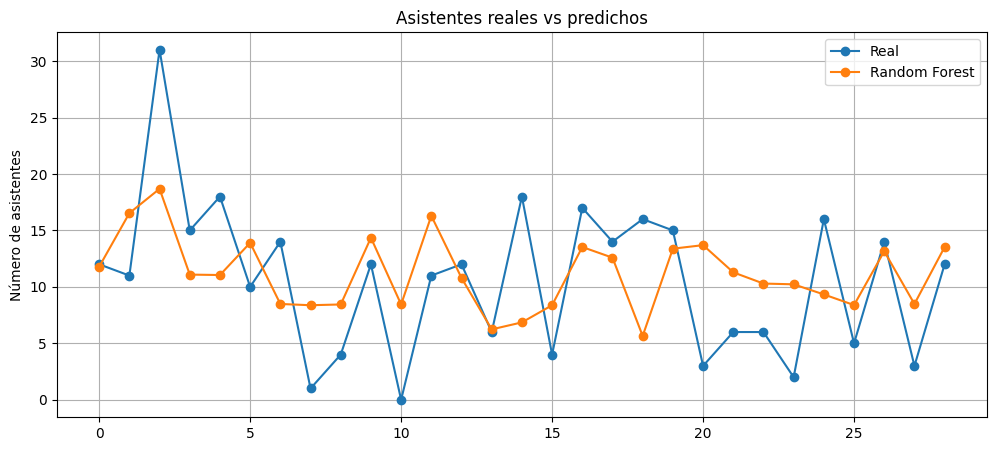

In [249]:
# Comparación entre asistentes reales y predichos

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Real",
    marker="o"
)

plt.plot(
    y_pred_rf,
    label="Random Forest",
    marker="o"
)

plt.title("Asistentes reales vs predichos")
plt.ylabel("Número de asistentes")

plt.legend()
plt.grid(True)

plt.show()

In [250]:
# Importancia de las variables predictoras

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
0,Mes,0.334673
10,Taller_Raíces,0.158464
1,Dia_Semana,0.145287
6,Taller_Kimchi,0.069252
5,Taller_Curso de Arroces,0.062638
2,Taller_Cocas Miquel Ruiz,0.048762
16,Taller_Tapas Españolas,0.039674
9,Taller_Ramen,0.038149
12,Taller_Sushi,0.024909
8,Taller_Paella Lovers,0.017312


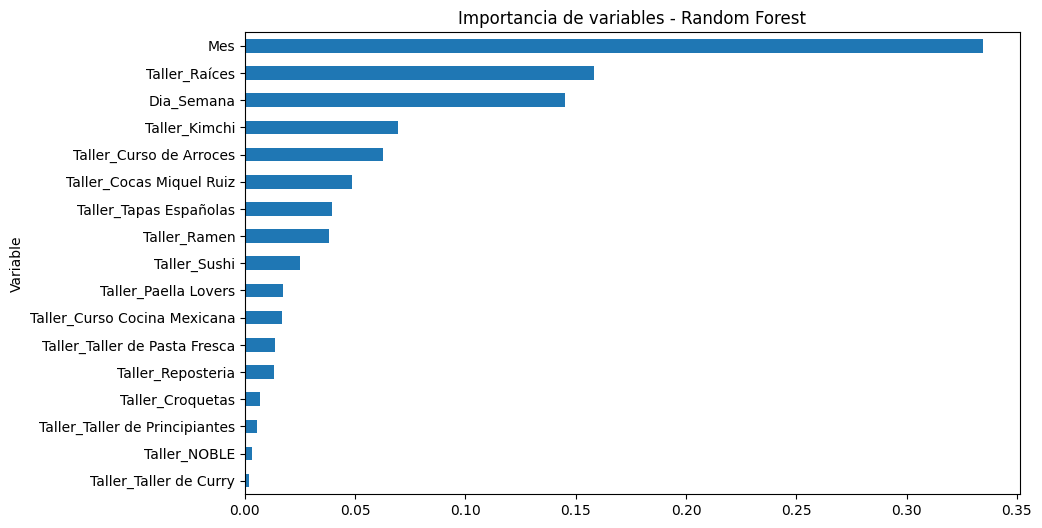

In [251]:
# Representación gráfica de la importancia de las variables

importancias.sort_values(
    by="Importancia",
    ascending=True
).plot(
    x="Variable",
    y="Importancia",
    kind="barh",
    figsize=(10,6),
    legend=False
)

plt.title("Importancia de variables - Random Forest")

plt.show()

Durante el análisis exploratorio se observó que el conjunto de datos incluía tanto talleres recurrentes como eventos especiales realizados de forma puntual. Estos últimos presentan características particulares y una frecuencia muy reducida, lo que dificulta la identificación de patrones consistentes y puede introducir ruido en los modelos predictivos.

Dado que el objetivo del estudio es estimar la ocupación futura de los talleres que forman parte de la oferta habitual de Food & Fun, se decidió restringir el análisis a aquellos cursos que se realizan de manera recurrente a lo largo del año. Entre ellos se incluyen los cursos de Arroces, Taller de Principiantes, Paella Lovers, Sushi, Ramen, Kimchi, Pasta Fresca, Repostería y Tapas Españolas.

Esta decisión permite trabajar con observaciones más homogéneas y representativas de la actividad habitual de la empresa, mejorando la capacidad de generalización de los modelos y facilitando la interpretación de los resultados. Asimismo, se debe considerar que algunos talleres presentan una estacionalidad propia. En particular, los cursos de Ramen y Kimchi se concentran principalmente durante los meses de otoño e invierno, mientras que su oferta disminuye significativamente en primavera y verano, aspecto que deberá tenerse en cuenta en la interpretación de los resultados predictivos.


In [252]:
resultados_finales = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],
    "R²": [
        0.275282,
        0.176343,
        -0.053687
    ],
    "MAE": [
        4.655608,
        5.050950,
        5.554193
    ],
    "RMSE": [
        5.661999,
        6.036128,
        6.827175
    ]
})

resultados_finales.round(3)

,Modelo,R²,MAE,RMSE
0,Regresión Lineal,0.275,4.656,5.662
1,Random Forest,0.176,5.051,6.036
2,XGBoost,-0.054,5.554,6.827


# 4. Delimitación de los talleres objeto de estudio


In [253]:
# Selección de talleres recurrentes

talleres_recurrentes = [
    "Curso de Arroces",
    "Taller de Principiantes",
    "Paella Lovers",
    "Sushi",
    "Ramen",
    "Kimchi",
    "Pasta Fresca",
    "Repostería",
    "Tapas Españolas"
]

ocupacion_talleres = ocupacion_talleres[
    ocupacion_talleres["Taller"].isin(
        talleres_recurrentes
    )
].copy()

In [254]:
# Filtrado de talleres recurrentes

ocupacion_talleres = ocupacion_talleres[
    ocupacion_talleres["Taller"].isin(
        talleres_recurrentes
    )
].copy()

In [255]:
# Comprobación del resultado

ocupacion_talleres.shape

(111, 8)

In [256]:
# Número de talleres por tipo

ocupacion_talleres["Taller"].value_counts()

Taller
Paella Lovers              28
Curso de Arroces           24
Sushi                      19
Tapas Españolas            18
Ramen                      12
Kimchi                      6
Taller de Principiantes     4
Name: count, dtype: int64

In [257]:
# Estadísticas descriptivas de la ocupación

ocupacion_talleres["Asistentes"].describe()

count    111.000000
mean      11.009009
std        5.850401
min        0.000000
25%        6.000000
50%       12.000000
75%       15.500000
max       22.000000
Name: Asistentes, dtype: float64

In [258]:
# Ocupación media por taller

ocupacion_talleres.groupby(
    "Taller"
)["Asistentes"].mean().sort_values(
    ascending=False
)

Taller
Kimchi                     17.333333
Ramen                      13.250000
Curso de Arroces           13.083333
Sushi                      11.578947
Paella Lovers               8.821429
Tapas Españolas             8.111111
Taller de Principiantes     8.000000
Name: Asistentes, dtype: float64

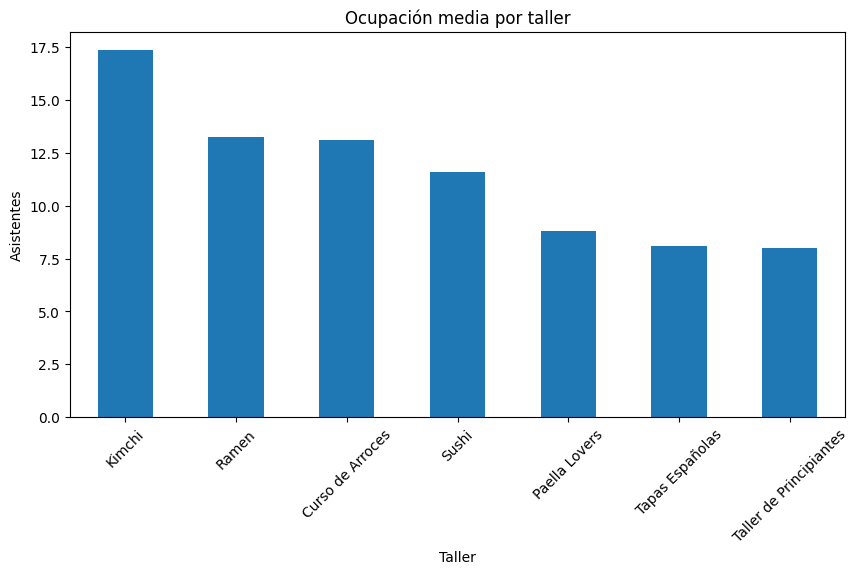

In [259]:
plt.figure(figsize=(10,5))

ocupacion_talleres.groupby(
    "Taller"
)["Asistentes"].mean().sort_values(
    ascending=False
).plot(
    kind="bar"
)

plt.title("Ocupación media por taller")
plt.xlabel("Taller")
plt.ylabel("Asistentes")

plt.xticks(rotation=45)

plt.show()

# 5. Desarrollo de modelos predictivos

## 5.1 Definición de variables predictoras (X) y variable objetivo (y)

In [260]:
# Variables predictoras

X = ocupacion_talleres[
    [
        "Taller",
        "Mes",
        "Dia_Semana"
    ]
]

# Variable objetivo

y = ocupacion_talleres["Asistentes"]

## 5.2 Transformación de variables categóricas

In [261]:
# One-Hot Encoding de la variable Taller

X = pd.get_dummies(
    X,
    columns=["Taller"],
    drop_first=True
)

## 5.3 División entrenamiento/prueba

In [262]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## 5.4 Regresión Lineal




In [263]:
# Entrenamiento del modelo de Regresión Lineal

from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [264]:
# Predicción del número de asistentes

y_pred_lr = modelo_lr.predict(
    X_test
)

In [265]:
# Evaluación del modelo

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

print("R² =", r2_lr)
print("MAE =", mae_lr)
print("RMSE =", rmse_lr)

R² = 0.07448963421594457
MAE = 4.547833487608619
RMSE = 5.3965692295759204


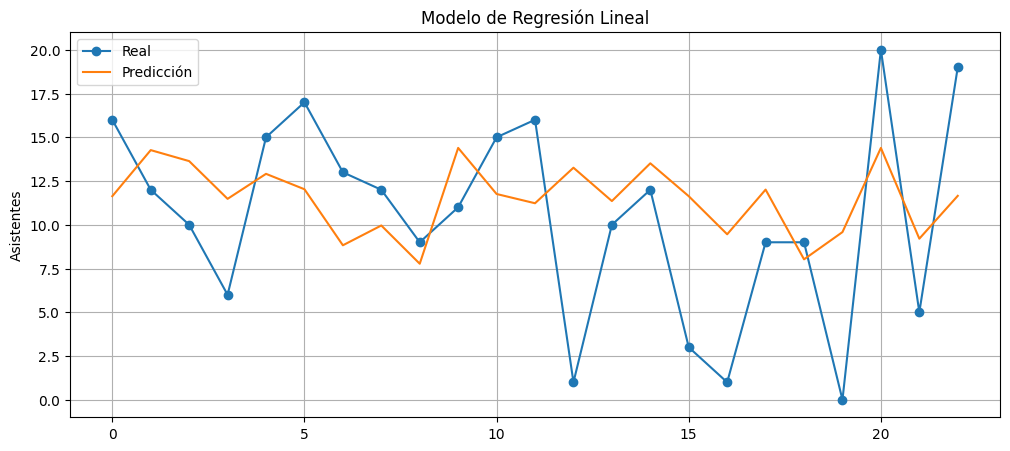

In [266]:
# Comparación entre asistentes reales y predichos

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Real",
    marker="o"
)

plt.plot(
    y_pred_lr,
    label="Predicción"
)

plt.title("Modelo de Regresión Lineal")
plt.ylabel("Asistentes")

plt.legend()
plt.grid(True)

plt.show()

## 5.5 Random Forest


In [267]:
# Entrenamiento del modelo Random Forest

from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

modelo_rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [268]:
# Predicción del número de asistentes

y_pred_rf = modelo_rf.predict(
    X_test
)

In [269]:
# Evaluación del modelo

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("R² =", r2_rf)
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)

R² = 0.06036393097222892
MAE = 4.197436086779099
RMSE = 5.437596142171794


In [270]:
# Importancia de las variables predictoras

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
0,Mes,0.427108
1,Dia_Semana,0.178042
7,Taller_Tapas Españolas,0.110328
3,Taller_Paella Lovers,0.081955
2,Taller_Kimchi,0.074702
4,Taller_Ramen,0.059663
5,Taller_Sushi,0.041533
6,Taller_Taller de Principiantes,0.026669


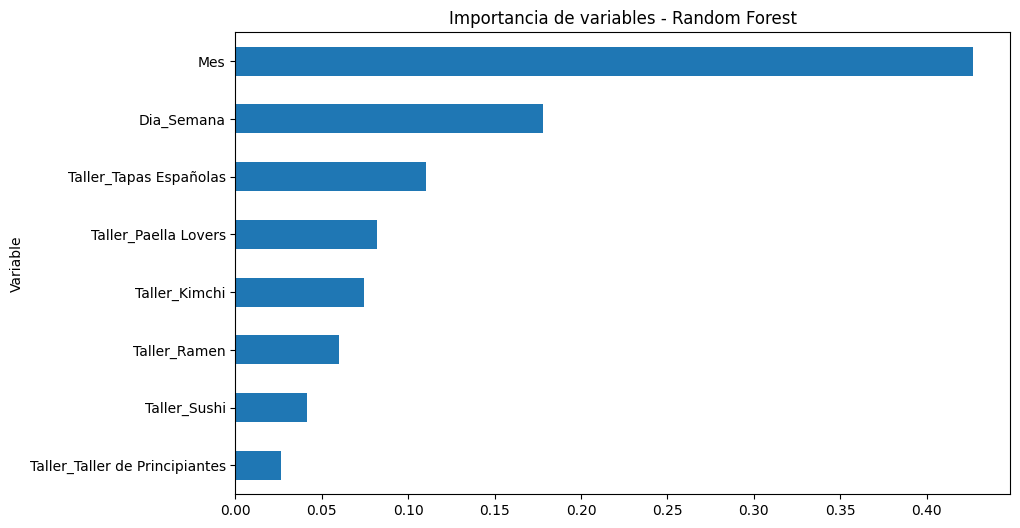

In [271]:
# Visualización de la importancia de las variables

importancias.sort_values(
    by="Importancia",
    ascending=True
).plot(
    x="Variable",
    y="Importancia",
    kind="barh",
    figsize=(10,6),
    legend=False
)

plt.title("Importancia de variables - Random Forest")

plt.show()

## 5.6 XGBoost

In [272]:
pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [273]:
# Entrenamiento del modelo XGBoost

from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

modelo_xgb.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [274]:
# Predicción del número de asistentes

y_pred_xgb = modelo_xgb.predict(
    X_test
)

In [275]:
# Evaluación del modelo

r2_xgb = r2_score(
    y_test,
    y_pred_xgb
)

mae_xgb = mean_absolute_error(
    y_test,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

print("R² =", r2_xgb)
print("MAE =", mae_xgb)
print("RMSE =", rmse_xgb)

R² = 0.003641188144683838
MAE = 4.293323516845703
RMSE = 5.599316262329787


In [276]:
# Comparación de resultados

resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],
    "R²": [
        r2_lr,
        r2_rf,
        r2_xgb
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ]
})

resultados

,Modelo,R²,MAE,RMSE
0,Regresión Lineal,0.074490,4.547833,5.396569
1,Random Forest,0.060364,4.197436,5.437596
2,XGBoost,0.003641,4.293324,5.599316


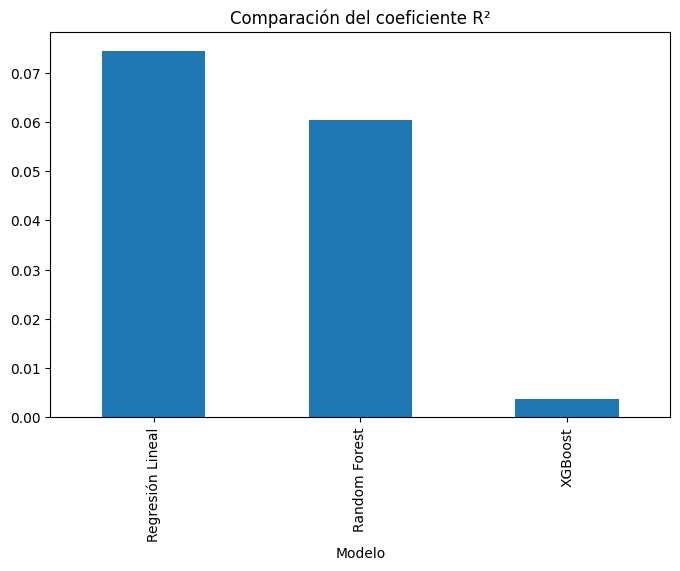

In [277]:
# Comparación gráfica del R²

resultados.plot(
    x="Modelo",
    y="R²",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Comparación del coeficiente R²")

plt.show()

## 5.7 Evaluación de los modelos y decisión final 
Los resultados obtenidos muestran una capacidad predictiva limitada en los tres modelos desarrollados. La Regresión Lineal alcanzó un coeficiente de determinación R² de 0,275, lo que indica que únicamente es capaz de explicar aproximadamente el 27,5% de la variabilidad observada en la ocupación de los talleres. Por su parte, el modelo Random Forest obtuvo un rendimiento inferior, mientras que XGBoost presentó un coeficiente R² negativo, indicando una capacidad predictiva insuficiente para el problema analizado.

Estos resultados sugieren que la ocupación de los talleres depende de factores adicionales que no se encuentran recogidos en el conjunto de datos utilizado. Variables como las acciones promocionales, campañas de marketing, festividades locales, antelación de la reserva, precio del taller o tendencias de consumo podrían tener una influencia significativa sobre la asistencia final.

En consecuencia, los modelos desarrollados no alcanzan un nivel de precisión suficiente para ser utilizados como herramienta principal de predicción de ocupación. Por ello, para la toma de decisiones empresariales se considera más adecuado apoyarse en el modelo de predicción de demanda desarrollado previamente, utilizando sus resultados para planificar acciones de marketing, promociones y campañas comerciales orientadas a incrementar la visibilidad y la captación de asistentes a los talleres.


### Interpretación de resultados

Los resultados obtenidos muestran que la capacidad predictiva de los modelos desarrollados para estimar la ocupación de los talleres es limitada.

La Regresión Lineal obtuvo el mejor rendimiento, alcanzando un coeficiente de determinación (R²) de 0,275. Este resultado indica que aproximadamente el 27,5% de la variabilidad observada en la ocupación puede explicarse mediante las variables incluidas en el modelo.

Por su parte, Random Forest obtuvo un R² de 0,176, mientras que XGBoost presentó un resultado negativo (-0,054), lo que indica un rendimiento inferior al obtenido utilizando simplemente la media de la variable objetivo.

Estos resultados sugieren que la ocupación de los talleres depende de factores adicionales no recogidos en la base de datos analizada, tales como campañas de marketing, condiciones meteorológicas, eventos locales, tendencias gastronómicas o cambios en las preferencias de los clientes.

En consecuencia, los modelos desarrollados no presentan una precisión suficiente para ser utilizados como herramienta principal de predicción operativa. Sin embargo, permiten identificar tendencias generales de comportamiento y sirven como apoyo complementario para la planificación de la oferta formativa.

In [278]:
resultados_finales.to_excel(
    "resultados_ocupacion.xlsx",
    index=False
)

# Graficos comparativos


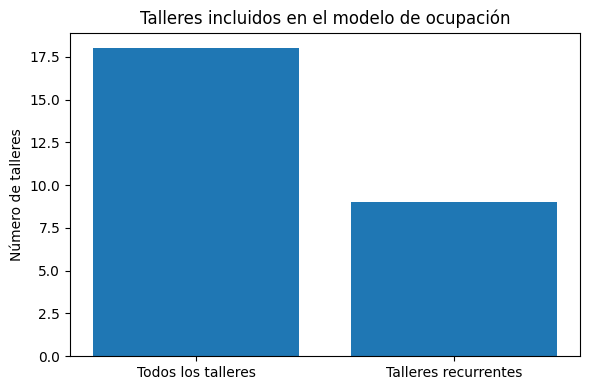

In [284]:
import matplotlib.pyplot as plt

antes = len(df["Taller"].unique())
despues = len(talleres_recurrentes)

plt.figure(figsize=(6,4))

plt.bar(
    ["Todos los talleres", "Talleres recurrentes"],
    [antes, despues]
)

plt.title("Talleres incluidos en el modelo de ocupación")
plt.ylabel("Número de talleres")

plt.tight_layout()
plt.show()

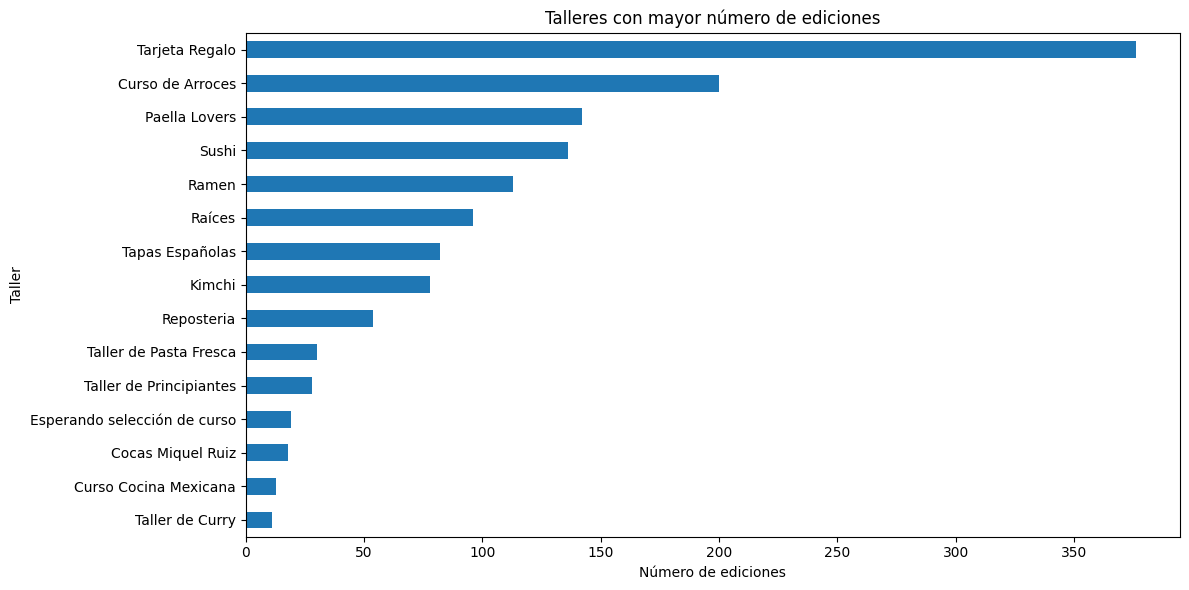

In [285]:
frecuencia = df["Taller"].value_counts()

plt.figure(figsize=(12,6))

frecuencia.head(15).sort_values().plot(kind="barh")

plt.title("Talleres con mayor número de ediciones")
plt.xlabel("Número de ediciones")
plt.ylabel("Taller")

plt.tight_layout()
plt.show()